In [1]:
import os

In [3]:
fp = "../../feature_extract_pipeline/target/_target_dist_cache.pkl"

In [5]:
import pickle

In [6]:
# 使用 'rb' 模式打开文件，并通过 pickle 加载数据
with open(fp, "rb") as f:
    target_dist_cache = pickle.load(f)

print("🎉 特征分布缓存加载成功！")
# 查看加载出来的对象类型（通常是 dict、DataFrame 或 numpy 数组）
print("数据类型:", type(target_dist_cache))

🎉 特征分布缓存加载成功！
数据类型: <class 'dict'>


In [8]:
# 1. 查看字典里所有的键 (Keys)，通常是特征名称
print("=" * 60)
print(f"📦 缓存中包含的键数量: {len(target_dist_cache)}")
print("=" * 60)
print("🔑 所有的键名 (Keys) 列表:")
for k in list(target_dist_cache.keys()):
    print(f" - {k}")
print("-" * 60)



📦 缓存中包含的键数量: 3
🔑 所有的键名 (Keys) 列表:
 - area_up
 - area_down
 - motion
------------------------------------------------------------


In [9]:
import numpy as np
import pandas as pd

print("=" * 60)
print("🔍 正在深度探测特征分布缓存的 Value 信息...")
print("=" * 60)

for key, value in target_dist_cache.items():
    print(f"\n🔑 特征键名: \033[1;31m{key}\033[0m")
    print(f"📊 数据类型: {type(value)}")
    print("-" * 40)
    
    # 类别 1：如果 Value 是字典（最常见：存储了各种统计标量）
    if isinstance(value, dict):
        print("📦 包含的统计分布参数 (Sub-keys & Values):")
        for sub_key, sub_val in value.items():
            # 格式化打印，如果是浮点数保留4位小数
            if isinstance(sub_val, (float, np.floating)):
                print(f"  🔹 {sub_key:<12} : {sub_val:.4f}")
            else:
                print(f"  🔹 {sub_key:<12} : {sub_val}")
                
    # 类别 2：如果 Value 是 NumPy 数组或 Python 列表（存储了原始分布采样点）
    elif hasattr(value, '__len__') and not isinstance(value, (str, pd.DataFrame, pd.Series)):
        print(f"📐 数组长度: {len(value)}")
        if hasattr(value, 'shape'):
            print(f"📐 数组形状: {value.shape}")
        
        # 尝试自动计算其统计特征，方便你肉眼观察
        try:
            arr = np.array(value, dtype=float)
            print("📈 探测到数值序列，自动计算历史分布基本面:")
            print(f"  🔹 历史均值 (Mean)   : {np.nanmean(arr):.4f}")
            print(f"  🔹 历史标准差 (Std)  : {np.nanstd(arr):.4f}")
            print(f"  🔹 历史范围 (Min~Max): {np.nanmin(arr):.4f} ~ {np.nanmax(arr):.4f}")
            print(f"  🔹 95% 分位数 (Q95)  : {np.nanpercentile(arr, 95):.4f}")
        except:
            print(f"  📄 前 5 项原始数据预览: {list(value)[:5]}")
            
    # 类别 3：如果 Value 是 Pandas DataFrame 或 Series
    elif isinstance(value, (pd.DataFrame, pd.Series)):
        print("🐼 探测到 Pandas 数据结构:")
        print(f"  📐 形状/结构: {value.shape}")
        print("  📄 数据基本描述 (describe):")
        print(value.describe())
        print("  📄 数据前 3 行预览:")
        print(value.head(3))
        
    # 类别 4：单个纯数值或字符串
    else:
        print(f"🎯 标量数值/内容: {value}")

print("\n" + "=" * 60)

🔍 正在深度探测特征分布缓存的 Value 信息...

🔑 特征键名: area_up
📊 数据类型: <class 'numpy.ndarray'>
----------------------------------------
📐 数组长度: 7786273
📐 数组形状: (7786273,)
📈 探测到数值序列，自动计算历史分布基本面:
  🔹 历史均值 (Mean)   : 1049.3118
  🔹 历史标准差 (Std)  : 945.8452
  🔹 历史范围 (Min~Max): 43.0000 ~ 4587.0000
  🔹 95% 分位数 (Q95)  : 2910.0000

🔑 特征键名: area_down
📊 数据类型: <class 'numpy.ndarray'>
----------------------------------------
📐 数组长度: 7785567
📐 数组形状: (7785567,)
📈 探测到数值序列，自动计算历史分布基本面:
  🔹 历史均值 (Mean)   : 1847.6065
  🔹 历史标准差 (Std)  : 1717.9243
  🔹 历史范围 (Min~Max): 105.0000 ~ 9241.0000
  🔹 95% 分位数 (Q95)  : 5029.0000

🔑 特征键名: motion
📊 数据类型: <class 'numpy.ndarray'>
----------------------------------------
📐 数组长度: 7864668
📐 数组形状: (7864668,)
📈 探测到数值序列，自动计算历史分布基本面:
  🔹 历史均值 (Mean)   : 16.3546
  🔹 历史标准差 (Std)  : 33.6310
  🔹 历史范围 (Min~Max): 0.0000 ~ 248.0000
  🔹 95% 分位数 (Q95)  : 87.0000



🚀 启动基于 Wasserstein 距离的领域自适应 (1D Optimal Transport)...
✅ [asc_area] 已成功向 [area_up] 的基准空间完成最优传输。
✅ [desc_area] 已成功向 [area_down] 的基准空间完成最优传输。
✅ [motion] 已成功向 [motion] 的基准空间完成最优传输。


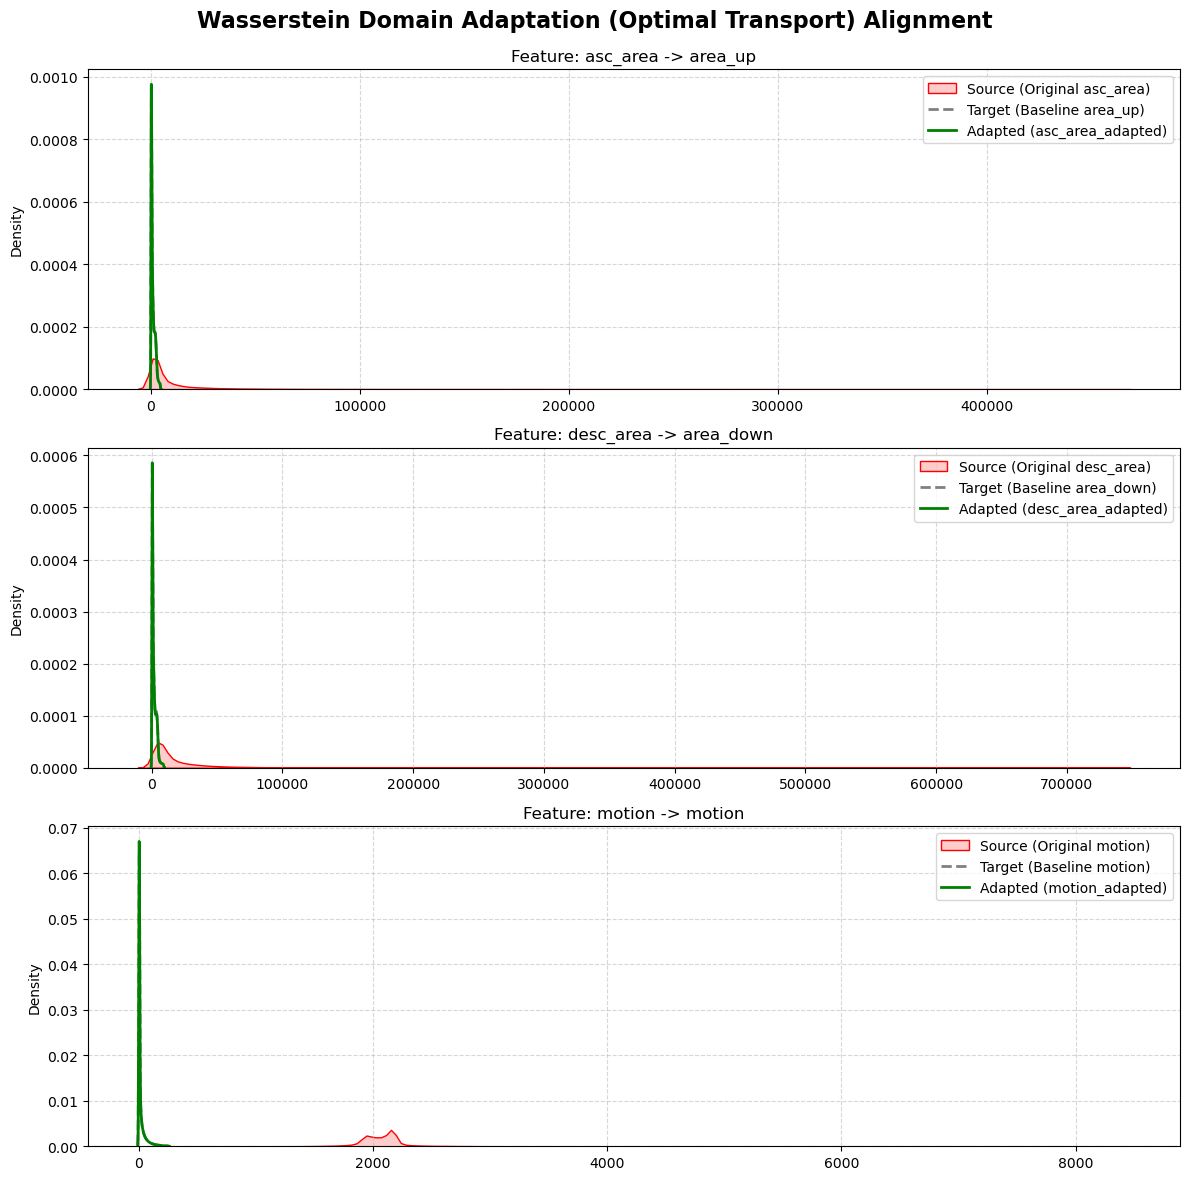


🎉 领域自适应完成！特征表已保存为 'features_1Hz_domain_adapted.csv'


In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
import seaborn as sns

print("=" * 60)
print("🚀 启动基于 Wasserstein 距离的领域自适应 (1D Optimal Transport)...")
print("=" * 60)

# 1. 核心算法：1D 最优传输映射 (分位数匹配)
def wasserstein_1d_adaptation(source, target):
    """
    通过最小化 Wasserstein 距离，将 source 分布完美映射到 target 分布。
    """
    # 剔除 NaN，保证计算纯净
    valid_mask = ~np.isnan(source)
    source_clean = source[valid_mask]
    target_clean = target[~np.isnan(target)]
    
    if len(source_clean) == 0 or len(target_clean) == 0:
        return source
        
    # 步骤 A：构建目标分布的逆 CDF (排序后的目标数组)
    target_sorted = np.sort(target_clean)
    
    # 步骤 B：计算源数据中每一个点在其自身分布中的累积概率 (Percentile/Rank)
    ranks = np.empty_like(source_clean)
    ranks[np.argsort(source_clean)] = np.arange(len(source_clean))
    percentiles = ranks / (len(source_clean) - 1) # 缩放到 0~1 之间
    
    # 步骤 C：构建插值函数 F_Y^{-1}(p)
    target_percentiles = np.linspace(0, 1, len(target_sorted))
    # 使用线性插值将源概率映射到目标的真实物理值上
    quantile_mapping = interp1d(target_percentiles, target_sorted, 
                                kind='linear', bounds_error=False, 
                                fill_value=(target_sorted[0], target_sorted[-1]))
    
    # 步骤 D：施加最优传输映射
    adapted_source_clean = quantile_mapping(percentiles)
    
    # 步骤 E：放回原来的数组（保留原本的 NaN 位置）
    adapted_source = np.full_like(source, np.nan)
    adapted_source[valid_mask] = adapted_source_clean
    
    return adapted_source

# 2. 数据准备
df_new = pd.read_csv('features_1Hz_interpolated.csv')
col_mapping = {
    'asc_area': 'area_up',
    'desc_area': 'area_down',
    'motion': 'motion'
}

# 准备画图的网格
fig, axes = plt.subplots(3, 1, figsize=(12, 12), facecolor='white')
fig.suptitle("Wasserstein Domain Adaptation (Optimal Transport) Alignment", fontsize=16, fontweight='bold')

# 3. 执行领域自适应与可视化对比
for idx, (new_col, cache_key) in enumerate(col_mapping.items()):
    if new_col in df_new.columns:
        source_data = df_new[new_col].values
        target_data = target_dist_cache[cache_key] # 这是一个长达几百万的 numpy 数组
        
        # 🔥 执行 Wasserstein 映射
        adapted_data = wasserstein_1d_adaptation(source_data, target_data)
        
        # 将自适应后的特征保存回 DataFrame
        df_new[f'{new_col}_adapted'] = adapted_data
        
        print(f"✅ [{new_col}] 已成功向 [{cache_key}] 的基准空间完成最优传输。")
        
        # ---------------- 可视化部分 ----------------
        ax = axes[idx]
        
        # 为了画图速度，如果 target 太大，我们随机抽样 5 万个点画图即可
        target_sample = np.random.choice(target_data, min(50000, len(target_data)), replace=False)
        
        # 画核密度估计图 (KDE)
        sns.kdeplot(source_data, ax=ax, color='red', label=f'Source (Original {new_col})', fill=True, alpha=0.2)
        sns.kdeplot(target_sample, ax=ax, color='gray', label=f'Target (Baseline {cache_key})', linestyle='--', linewidth=2)
        sns.kdeplot(adapted_data, ax=ax, color='green', label=f'Adapted ({new_col}_adapted)', linewidth=2)
        
        ax.set_title(f"Feature: {new_col} -> {cache_key}", fontsize=12)
        ax.legend()
        ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.subplots_adjust(top=0.93)
plt.show()

# 4. 导出最终可用数据
df_new.to_csv('features_1Hz_domain_adapted.csv', index=False)
print("\n🎉 领域自适应完成！特征表已保存为 'features_1Hz_domain_adapted.csv'")

In [13]:
da = pd.read_csv("features_1Hz_domain_adapted.csv")

In [14]:
da.head()

,peak_time,HR_BPM,asc_area,desc_area,motion,asc_area_adapted,desc_area_adapted,motion_adapted
0,2026-05-02 16:21:46,31.250000,1584.841063,14430.394945,1986.352688,376.0,1901.0,1.0
1,2026-05-02 16:21:47,78.947368,1590.709659,4772.128978,1990.035929,378.0,547.0,1.0
2,2026-05-02 16:21:48,83.349412,2239.360734,5627.556008,1995.333711,510.0,635.0,1.0
3,2026-05-02 16:21:49,84.507042,1804.429021,4938.437320,1996.115478,416.0,565.0,1.0
4,2026-05-02 16:21:50,76.923077,2178.546028,5913.196361,1990.484614,495.0,666.0,1.0


In [22]:
import pandas as pd

print("正在精简特征表、补充 RRI 并对特征进行整数格式化...")

# 1. 读取刚才生成的领域自适应特征表
da = pd.read_csv("features_1Hz_domain_adapted.csv")

# ====================================================================
# 🌟 新增核心逻辑：找回心率并计算 RRI (毫秒级整数)
# ====================================================================
# 如果原表有 HR_BPM，通过 60000 / HR 算出毫秒；如果是 IBI_sec，直接乘 1000
if 'HR_BPM' in da.columns:
    da['rri_ms'] = (60000.0 / da['HR_BPM'])
elif 'IBI_sec' in da.columns:
    da['rri_ms'] = (da['IBI_sec'] * 1000)
else:
    print("⚠️ 警告：源数据中找不到 HR_BPM 或 IBI_sec 列！")

# 2. 定义我们最终决定保留的列名 (将 'rri_ms' 加入保留名单)
target_cols = ['peak_time', 'rri_ms', 'asc_area_adapted', 'desc_area_adapted', 'motion_adapted']

# 仅切片提取这几列
df_slim = da[target_cols].copy()

# ====================================================================
# 🌟 核心处理：将所有物理特征安全转换为整数格式 (完美兼容 NaN)
# ====================================================================
# 现在把 rri_ms 也放进需要整数化的列表里
feature_cols = ['rri_ms', 'asc_area_adapted', 'desc_area_adapted', 'motion_adapted']

for col in feature_cols:
    # 先四舍五入保留最接近的整数，再转为 Pandas 专有的 'Int64' (大写I，支持 NaN)
    df_slim[col] = df_slim[col].round().astype('Int64')

# ====================================================================

# 3. 打印精简后的特征表预览，检查列名和数据类型
print("=" * 60)
print("🎉 特征表精简与整数格式化成功！")
print("=" * 60)
print("\n[ 数据前 5 行预览 ]")
print(df_slim.head().to_string())
print("-" * 60)
print("\n[ 各列字段类型审查 (dtypes) ]")
print(df_slim.dtypes)
print("=" * 60)

# 4. 导出最终版的极简特征 CSV
output_fp = "features_1Hz_final_integer.csv"
df_slim.to_csv(output_fp, index=False)
print(f"💾 最终版模型就绪特征表已安全保存至: '{output_fp}'")

正在精简特征表、补充 RRI 并对特征进行整数格式化...
🎉 特征表精简与整数格式化成功！

[ 数据前 5 行预览 ]
             peak_time  rri_ms  asc_area_adapted  desc_area_adapted  motion_adapted
0  2026-05-02 16:21:46    1920               376               1901               1
1  2026-05-02 16:21:47     760               378                547               1
2  2026-05-02 16:21:48     720               510                635               1
3  2026-05-02 16:21:49     710               416                565               1
4  2026-05-02 16:21:50     780               495                666               1
------------------------------------------------------------

[ 各列字段类型审查 (dtypes) ]
peak_time              str
rri_ms               Int64
asc_area_adapted     Int64
desc_area_adapted    Int64
motion_adapted       Int64
dtype: object
💾 最终版模型就绪特征表已安全保存至: 'features_1Hz_final_integer.csv'


In [23]:
import pandas as pd
import numpy as np

def encode_dataframe_to_hex(df, output_file='hex_may_compressed.txt'):
    """
    将等距 1Hz 最终版特征表编码为紧凑的 16 进制格式并保存到 TXT 文件中。
    (终极纯净版：无空白占位)
    """
    df_code = df.copy()
    
    # 1. 确保时间轴是 datetime 对象
    df_code['peak_time'] = pd.to_datetime(df_code['peak_time'])
    
    # 2. 建立毫秒时序基准 (rri_ms)
    if 'IBI_sec' in df_code.columns:
        df_code['rri_ms'] = (df_code['IBI_sec'] * 1000).fillna(0).round().astype(int)
    elif 'rri_ms' in df_code.columns:
        df_code['rri_ms'] = df_code['rri_ms'].fillna(0).round().astype(int)
    else:
        df_code['rri_ms'] = 1000

    # 3. 映射特征列名
    cols_mapping = {
        'asc_area_adapted': 'asc_area',
        'desc_area_adapted': 'desc_area',
        'motion_adapted': 'motion'
    }
    
    for src_col, target_col in cols_mapping.items():
        if src_col in df_code.columns:
            df_code[target_col] = df_code[src_col].fillna(0).round().astype(int)
        elif target_col in df_code.columns:
            df_code[target_col] = df_code[target_col].fillna(0).round().astype(int)
        else:
            df_code[target_col] = 0

    blocks = []
    last_timestamp = None
    current_block = ""
    
    print("⏳ 正在启动逐行 16 进制流式压缩编码 (纯净模式)...")
    
    # 4. 逐行执行高密度 HEX 压缩
    for _, row in df_code.iterrows():
        ts_unix = int(row['peak_time'].timestamp())
        
        # 严格限制 16 进制位宽：3位, 5位, 5位, 4位
        rri_hex    = f"{row['rri_ms']:03X}"
        asc_hex    = f"{row['asc_area']:05X}"
        desc_hex   = f"{row['desc_area']:05X}"
        motion_hex = f"{row['motion']:04X}"
        
        data_str = rri_hex + asc_hex + desc_hex + motion_hex
        
        if ts_unix != last_timestamp:
            if current_block:
                blocks.append(current_block)
            
            ts_hex = f"{ts_unix:08X}"
            current_block = ts_hex + data_str
            last_timestamp = ts_unix
        else:
            current_block += data_str
            
    if current_block:
        blocks.append(current_block)
        
    final_output = " ".join(blocks)
    
    with open(output_file, 'w', encoding='utf-8') as f:
        f.write(final_output)
        
    print(f"==================================================")
    print(f"🎉 终极纯净版 16进制数据流协议编码大功告成！")
    print(f"💾 极限压缩文件已保存至: '{output_file}'")
    print(f"📏 有效生理数据块数量: {len(blocks)} 块")
    print(f"📝 密文前120个字符预览:\n{final_output[:120]}...")
    print(f"==================================================")
    
    return final_output

# ==========================================
# Jupyter 核心触发入口
# ==========================================
if __name__ == '__main__':
    # 1. 直接读取你的目标表格
    df = pd.read_csv("./features_1Hz_final_integer.csv")
    
    print(f"🧹 清理前总行数 (含空白占位): {len(df)}")
    
    # 🌟 核心清理动作：剔除插值无法覆盖的空白期（即 NaN 所在的行）
    # 这样能把全 0 的无用数据彻底干掉！
    df_clean = df.dropna(subset=['asc_area_adapted'])
    
    print(f"✨ 清理后有效数据行数: {len(df_clean)}")
    
    # 2. 触发转换 (生成压缩版本的文件)
    encode_dataframe_to_hex(df_clean, 'hex_may.txt')

🧹 清理前总行数 (含空白占位): 94734
✨ 清理后有效数据行数: 62538
⏳ 正在启动逐行 16 进制流式压缩编码 (纯净模式)...
🎉 终极纯净版 16进制数据流协议编码大功告成！
💾 极限压缩文件已保存至: 'hex_may.txt'
📏 有效生理数据块数量: 62538 块
📝 密文前120个字符预览:
69F6249A780001780076D0001 69F6249B2F80017A002230001 69F6249C2D0001FE0027B0001 69F6249D2C6001A0002350001 69F6249E30C001EF...
